# Phase 0: Foundations

**Skill:** agent-based-model basics and determinism.

Phase 0 builds the smallest world that is honest about its bookkeeping:

- a 64×64 grid where 1 tick = 1 sim-hour (a year is 8,760 ticks)
- one seeded RNG stream per system (`init`, `weather`, `plants`)
- a weather generator, a soil-water bucket per cell, and plants with explicit carbon pools
- a ledger that books every carbon and water flow and fails the run on any unexplained gain or loss
- a replay record (seed, sim version, params, accepted intents) that re-runs bit-identically
- a thin matplotlib debug viewer

**Done when:** a headless 1-year run completes, replays bit-identically, and the carbon mass-balance test passes in CI.

Run this notebook with `uv sync --group notebooks` then `uv run jupyter lab`.

In [1]:
import os, sys
from pathlib import Path

# Run from the repo root so `sim` imports resolve whether Jupyter starts in notebooks/ or the root.
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np

from sim import TICKS_PER_DAY, TICKS_PER_YEAR
from sim.engine import Simulation
from sim.intents import Disturb
from sim.replay import ReplayMismatch, record_run, replay
from sim.viewer import grid_figure, timeseries_figure

%matplotlib inline

## 1. One year, headless

The tick order is fixed: apply intents → weather → soil water → carbon → balance check. Nothing in the loop waits on anything outside it.

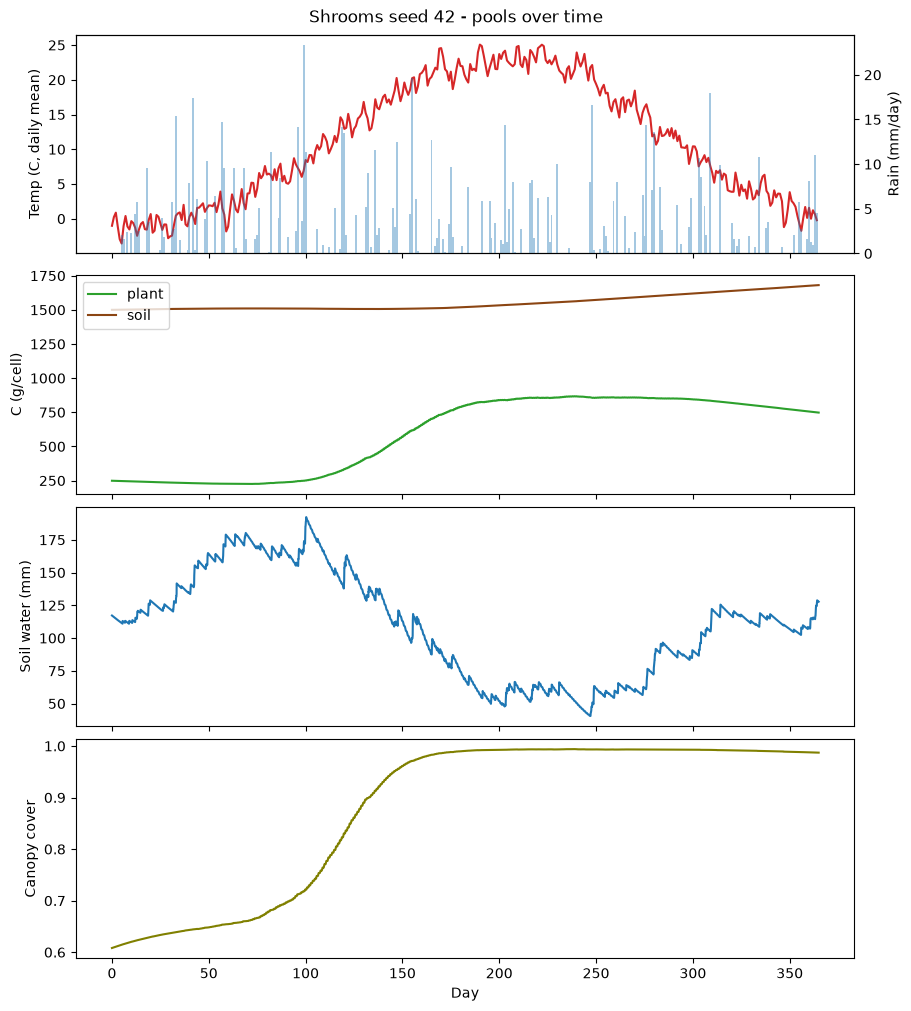

In [2]:
sim = Simulation(seed=42)
sim.run(TICKS_PER_YEAR)
timeseries_figure(sim);

Read the plot top to bottom. Spring warmth and light drive growth from about day 100. Summer transpiration draws soil water down, and plants plateau as water stress and crowding bite. Autumn and winter respiration then slowly eat into biomass. Soil carbon rises all year because litterfall outpaces decomposition (more on that in *What broke*).

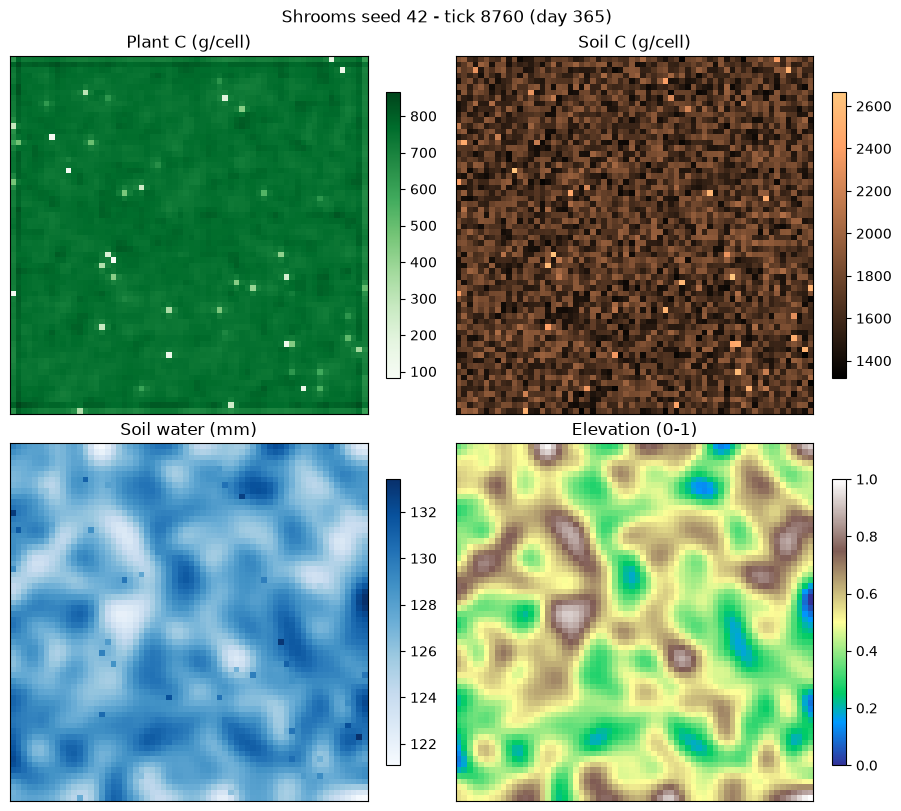

In [3]:
grid_figure(sim);

## 2. The carbon budget

Carbon lives in three places: the atmosphere (one scalar pool), plant biomass and soil, per cell. Every flow is booked by name in the ledger:

```
atmosphere --gpp----------------> plant
plant ------autotrophic_resp----> atmosphere
plant ------litterfall----------> soil
plant ------disturbance---------> soil
soil -------heterotrophic_resp--> atmosphere
plant ------dispersal-----------> neighbouring plant   (internal)
```

Two checks run every tick: total carbon must equal its t0 value, and land carbon (plant + soil) must equal t0 + GPP − respiration.

In [4]:
n = sim.state.plant_c.size
flows = {k: v / n for k, v in sim.ledger.totals.items() if k not in ("rain", "evapotranspiration", "drainage")}
for k, v in flows.items():
    print(f"{k:>20}: {v:8.1f} g C per cell per year")

land_change = (sim.state.land_carbon() - sim.ledger.land_c_t0) / n
explained = flows["gpp"] - flows["autotrophic_resp"] - flows["heterotrophic_resp"]
print(f"\nland C change {land_change:.6f}  explained by flows {explained:.6f}")
print(f"total C drift {sim.state.total_carbon() - sim.ledger.carbon_t0:+.3e} g (float rounding only)")

                 gpp:   1296.0 g C per cell per year
    autotrophic_resp:    474.7 g C per cell per year
          litterfall:    312.5 g C per cell per year
         disturbance:      9.8 g C per cell per year
  heterotrophic_resp:    141.4 g C per cell per year

land C change 679.877430  explained by flows 679.877430
total C drift -1.550e-06 g (float rounding only)


## 3. Determinism

Three things make a run reproducible:

1. **Per-system RNG streams.** Each system draws from its own PCG64 generator keyed by `(seed, CRC32(name))`. Adding a draw to plants never shifts the weather. Python's `hash()` is salted per process, so it's avoided.
2. **Fixed draw order.** The weather step makes the same three draws every tick whether or not it's raining, so the stream can't drift between code paths.
3. **State hashing.** `Simulation.state_hash()` is SHA-256 over every world field's raw float64 bytes **plus every RNG stream's position**. "Same" means bit-identical, not approximately equal.

In [5]:
a, b = Simulation(7), Simulation(7)
b.rng["plants"].random(10_000)          # burn plant randomness in b only
a.run(48); b.run(48)
print("weather identical despite extra plant draws:", a.history["temp_c"] == b.history["temp_c"])
print("world state still identical:               ", a.state.state_hash() == b.state.state_hash())
print("full hash (world + RNG positions) differs: ", a.state_hash() != b.state_hash())

weather identical despite extra plant draws: True
world state still identical:                True
full hash (world + RNG positions) differs:  True


The middle line is the trap. The plant stream only feeds rare disturbances, so 48 ticks of a drifted stream left no mark on the world. A world-only hash would call these runs identical right up until a disturbance fired somewhere different. That's why the replay hash includes RNG positions.

## 4. Intents and replay

In Phase 2, LLM agents will act only by submitting typed intents that the sim validates. Phase 0 has one debug intent, `disturb`, so the path is exercised from end to end. A replay record stores only *accepted* intents, with the tick each was applied, plus checkpoint hashes every 730 ticks.

In [6]:
clearing = Disturb(tick=2000, x0=16, y0=16, x1=48, y1=48, fraction=1.0)
bad = Disturb(tick=2000, x0=60, y0=0, x1=80, y1=8, fraction=1.0)   # out of bounds

run, record = record_run(seed=42, ticks=TICKS_PER_YEAR, intents=[clearing, bad])
print("accepted:", [i.kind for i in record.intents])
print("rejected:", [reason for _, reason in run.rejected])

again = replay(record)
print("replay bit-identical:", again.state_hash() == record.final_hash)

tampered = record.model_copy(update={"intents": [clearing.model_copy(update={"fraction": 0.9})]})
try:
    replay(tampered)
except ReplayMismatch as err:
    print("tampered replay caught:", err)

accepted: ['disturb']
rejected: ["rectangle out of bounds for 64x64 grid: tick=2000 kind='disturb' x0=60 y0=0 x1=80 y1=8 fraction=1.0"]


replay bit-identical: True


tampered replay caught: diverged between tick 1460 and 2190


## 5. Something emergent: a recolonization front

Nothing in the rules says "recover from the edges inward." Each cell only exports a small share of its biomass to its four neighbours, and those neighbours then grow it with their own photosynthesis. Together those two local rules produce a front that moves inward over about three years.

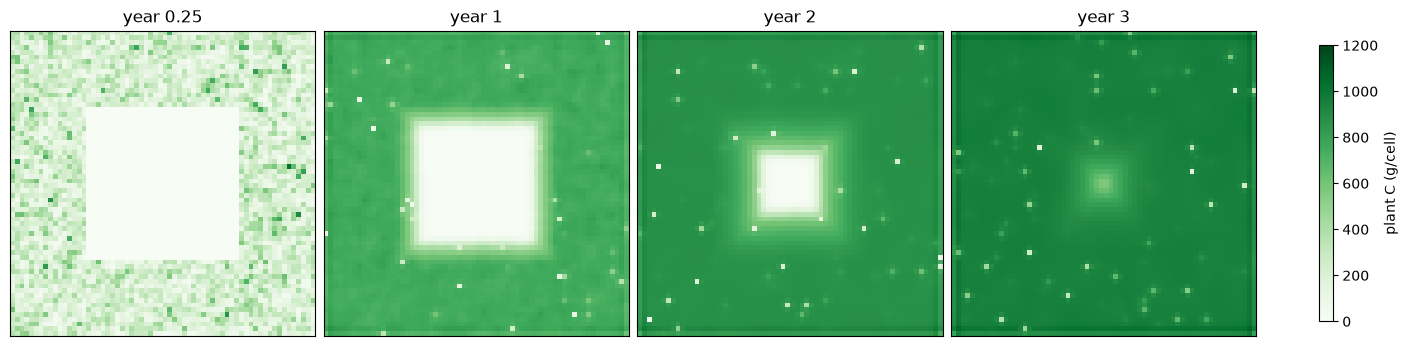

In [7]:
sim = Simulation(seed=42)
sim.submit([clearing])
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), constrained_layout=True)
for ax, years in zip(axes, (0.25, 1, 2, 3)):
    sim.run(int(years * TICKS_PER_YEAR) - sim.state.tick)
    im = ax.imshow(sim.state.plant_c, cmap="Greens", vmin=0, vmax=1200, interpolation="nearest")
    ax.set_title(f"year {years:g}")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.8, label="plant C (g/cell)");

## 6. Terrain shows up in water before it shows up in plants

Valley cells (low elevation) get up to 60% more water capacity. By late summer that difference shows up clearly in soil water, but only weakly in biomass, because dispersal keeps smoothing plant carbon across neighbours.

corr(elevation, water) = -0.99   corr(elevation, plant C) = -0.03


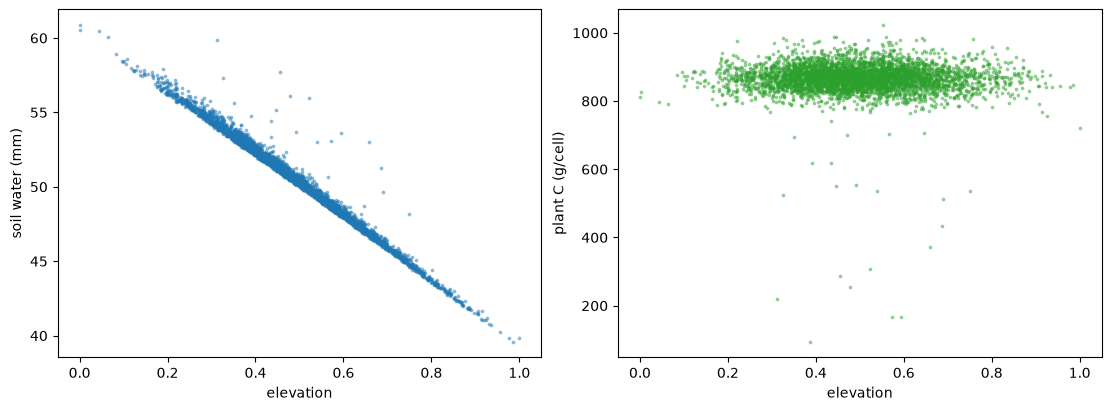

In [8]:
sim = Simulation(seed=42)
sim.run(240 * TICKS_PER_DAY)  # late August
e = sim.state.elevation.ravel()
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].scatter(e, sim.state.soil_water.ravel(), s=3, alpha=0.4)
axes[0].set(xlabel="elevation", ylabel="soil water (mm)")
axes[1].scatter(e, sim.state.plant_c.ravel(), s=3, alpha=0.4, color="tab:green")
axes[1].set(xlabel="elevation", ylabel="plant C (g/cell)")
r_w = np.corrcoef(e, sim.state.soil_water.ravel())[0, 1]
r_p = np.corrcoef(e, sim.state.plant_c.ravel())[0, 1]
print(f"corr(elevation, water) = {r_w:+.2f}   corr(elevation, plant C) = {r_p:+.2f}")

## What broke (and what's still wrong)

**Fixed during Phase 0**

- **The world hash missed RNG drift.** Replay originally hashed only world state. This notebook's determinism demo showed two runs with different plant-RNG positions hashing identically, because no disturbance had fired yet. Replay checkpoints now include every stream's `bit_generator.state`.
- **The carbon check was too loose.** The first version compared total carbon against its t0 value with a relative tolerance. The atmosphere pool is 1e9 g, so any leak under about 0.1 g passed silently. The fix adds a second check that reconciles land carbon (plant + soil, about 8e6 g) against booked GPP minus respiration. A test now injects a 10 mg leak and expects a failure.
- **Vite rejected PixiJS v8's top-level `await`.** Vite's default build target is too old for it, so the build config now targets ES2022.

**Known issues, deferred on purpose**

- **Soil carbon isn't at equilibrium.** Litterfall (about 320 g/cell/yr) outpaces decomposition (about 140), so soil C climbs around 300 g/cell/yr. Before generating datasets in Phase 4, runs need a spin-up period, or decomposition needs retuning in Phase 1 once saprotrophs and bacteria exist.
- **The field is homogeneous.** Weather is uniform across the plot and dispersal smooths biomass, so terrain barely shows in plants (section 6). Lateral hydrology in Phase 1 should give valleys and ridges distinct ecologies.
- **There's no seed bank.** A fully cleared cell can only be recolonized from its neighbours, so large clearings take years to fill in. That's arguably right for trees and wrong for grasses.
- **Determinism is per platform.** Replay is bit-identical on the same machine and numpy build. Transcendental functions (`exp`, `**`) can differ in the last bit across CPUs and libm versions, so a record made on a laptop isn't guaranteed to replay bit-exactly in CI. If that's ever needed, the options are fixed-point pools or a float-tolerant comparison mode.
- **Speed.** A year takes about 2.5 s (roughly 3,500 ticks/s) with pure numpy. Phase 4 targets at least 1,000 ticks/s with far more going on, so Numba or batched runs will be needed.

## Try it

1. Set `disturbance_prob` to 1e-4 and watch the field turn into a patchwork of successional ages.
2. Break determinism on purpose: draw weather noise only when it's raining. Which test fails first?
3. Remove the `np.minimum(rh, soil_c)` cap and set `decomposition_rate_20c=0.5`. Does the ledger catch the negative pool, and how?